generacion de clusters de clientes 

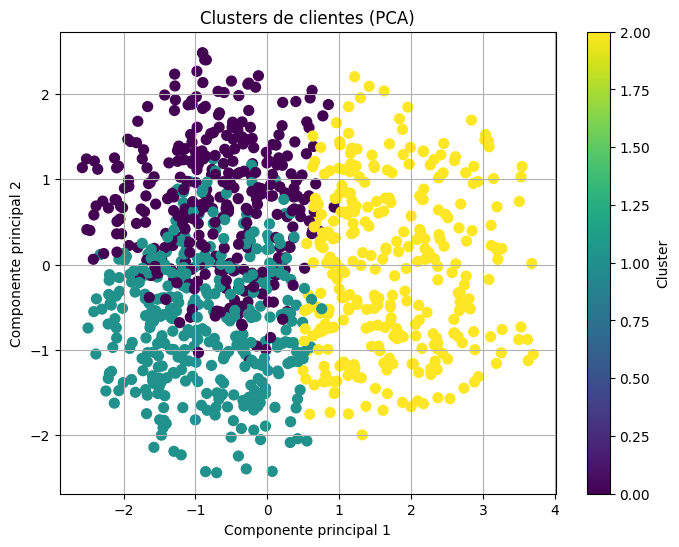

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Cargar datos

url = "https://raw.githubusercontent.com/restevesd/fuentes/main/supermarket_sales.csv"
df = pd.read_csv(url)



# Columnas
num_cols = ["Total", "Unit price", "Rating", "Quantity"]
cat_cols = ["Customer type", "Gender", "Product line", "Payment"]

# Preprocesamiento
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(), cat_cols)
])

# Pipeline de clustering
pipeline = Pipeline([
    ("prep", preprocessor),
    ("cluster", KMeans(n_clusters=3, random_state=42))
])

# Ajustar pipeline
pipeline.fit(df)

# Obtener datos transformados
X_transformed = pipeline.named_steps["prep"].transform(df)
labels = pipeline.named_steps["cluster"].labels_

# Reducir a 2D con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)

# Graficar
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="viridis", s=50)
plt.title("Clusters de clientes (PCA)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()


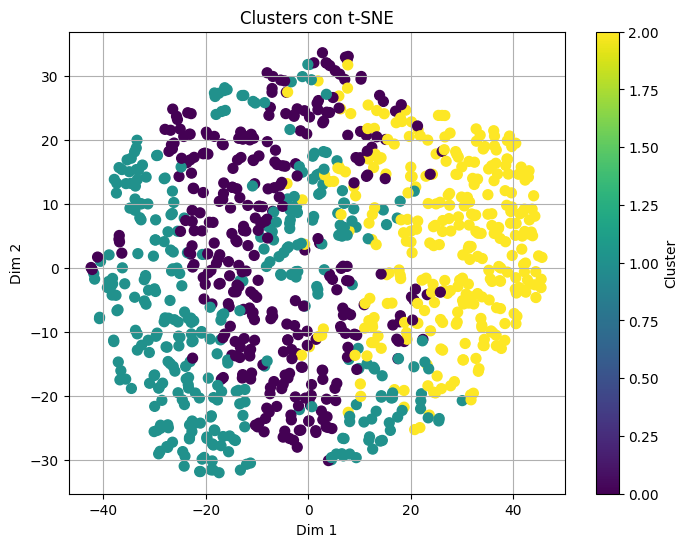

In [3]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_transformed)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap="viridis", s=50)
plt.title("Clusters con t-SNE")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

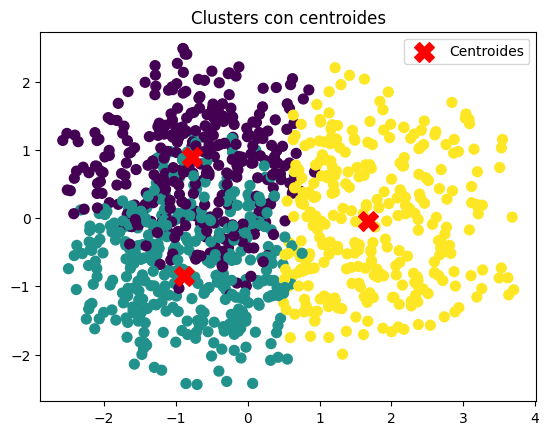

In [4]:
centroids = pipeline.named_steps["cluster"].cluster_centers_
centroids_pca = PCA(n_components=2).fit_transform(centroids)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="viridis", s=50)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], c="red", marker="X", s=200, label="Centroides")
plt.legend()
plt.title("Clusters con centroides")
plt.show()

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

# Cargar datos
url = "https://raw.githubusercontent.com/restevesd/fuentes/main/supermarket_sales.csv"
df = pd.read_csv(url)

# Columnas solicitadas
num_cols = ["Total", "Unit price", "Rating", "Quantity"]
cat_cols = ["Customer type", "Gender", "Product line", "Payment"]

# Mantener solo las columnas necesarias (y la columna para hover)
cols_needed = ["Invoice ID"] + num_cols + cat_cols
df_sub = df[cols_needed].copy()

# Opcional: eliminar filas con valores faltantes en las columnas usadas
df_sub = df_sub.dropna(subset=num_cols + cat_cols).reset_index(drop=True)

# Preprocesamiento: escalar numéricas y OneHotEncode categóricas
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

X_transformed = preprocessor.fit_transform(df_sub)

# KMeans con k = 5
k = 5
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X_transformed)

# PCA a 3 componentes para visualización
pca = PCA(n_components=3, random_state=42)
X_pca3 = pca.fit_transform(X_transformed)

# Centroides en el espacio PCA
centroids_pca = pca.transform(km.cluster_centers_)

# Preparar DataFrame para plotly (añadir columnas para hover)
pca_df = pd.DataFrame(X_pca3, columns=["PC1", "PC2", "PC3"])
pca_df["Cluster"] = labels.astype(str)
pca_df["Invoice ID"] = df_sub["Invoice ID"].astype(str)
pca_df["Total"] = df_sub["Total"]
pca_df["Product line"] = df_sub["Product line"]

# Gráfico 3D interactivo con Plotly
fig = px.scatter_3d(
    pca_df,
    x="PC1", y="PC2", z="PC3",
    color="Cluster",
    hover_data=["Invoice ID", "Total", "Product line"],
    title=f"KMeans k={k} proyectado en PCA(3) usando columnas seleccionadas",
    width=1000, height=700
)

# Añadir centroides como cruces negras
centroids_trace = go.Scatter3d(
    x=centroids_pca[:, 0],
    y=centroids_pca[:, 1],
    z=centroids_pca[:, 2],
    mode="markers",
    marker=dict(size=8, color="black", symbol="x"),
    name="Centroides"
)
fig.add_trace(centroids_trace)

fig.update_layout(legend_title_text="Cluster")
fig.show()

# Guardar etiquetas en el CSV para análisis posterior
df_sub["Cluster_k5"] = labels
df_sub.to_csv("clientes_cluster_k5_pca3.csv", index=False)

# Guardar gráfico interactivo como HTML
fig.write_html("clusters_k5_pca3.html")

In [10]:
import pandas as pd
from sklearn.feature_extraction import FeatureHasher

# 1. crear columna combinada
df['combo'] = df['Customer type'].astype(str) + '_' + df['Gender'].astype(str) + '_' + df['Product line'].astype(str)

# 2. frecuencias y agrupar raros
freq = df['combo'].value_counts(normalize=False)
rare = freq[freq < 10].index  # umbral absoluto
df['combo_grouped'] = df['combo'].where(~df['combo'].isin(rare), 'Other')

# 3a. frequency encoding (útil para clustering)
freq_map = df['combo_grouped'].value_counts(normalize=True).to_dict()
df['combo_freq'] = df['combo_grouped'].map(freq_map)

# 3b. hashing (evita explosion dimensional)
hasher = FeatureHasher(n_features=16, input_type='string')
hashed = hasher.transform(df['combo_grouped'].astype(str).apply(lambda x: [x]))
hashed_df = pd.DataFrame(hashed.toarray(), columns=[f'hash_{i}' for i in range(16)])
df = pd.concat([df.reset_index(drop=True), hashed_df.reset_index(drop=True)], axis=1)

# 3c. top-N one-hot (si quieres interpretabilidad)
topN = freq.nlargest(20).index
df['combo_topN'] = df['combo'].where(df['combo'].isin(topN), 'Other')
df = pd.get_dummies(df, columns=['combo_topN'], prefix='combo')

In [12]:
df.head(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,...,combo_Normal_Female_Fashion accessories,combo_Normal_Female_Food and beverages,combo_Normal_Female_Sports and travel,combo_Normal_Male_Electronic accessories,combo_Normal_Male_Fashion accessories,combo_Normal_Male_Food and beverages,combo_Normal_Male_Health and beauty,combo_Normal_Male_Home and lifestyle,combo_Normal_Male_Sports and travel,combo_Other
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,False,False,False,False,False,False,False,False,False,True
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,False,False,False,False,False,False,False,False,False,False
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,...,False,False,False,False,False,False,False,True,False,False
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,...,False,False,False,False,False,False,False,False,False,False
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,...,False,False,False,False,False,False,False,False,True,False


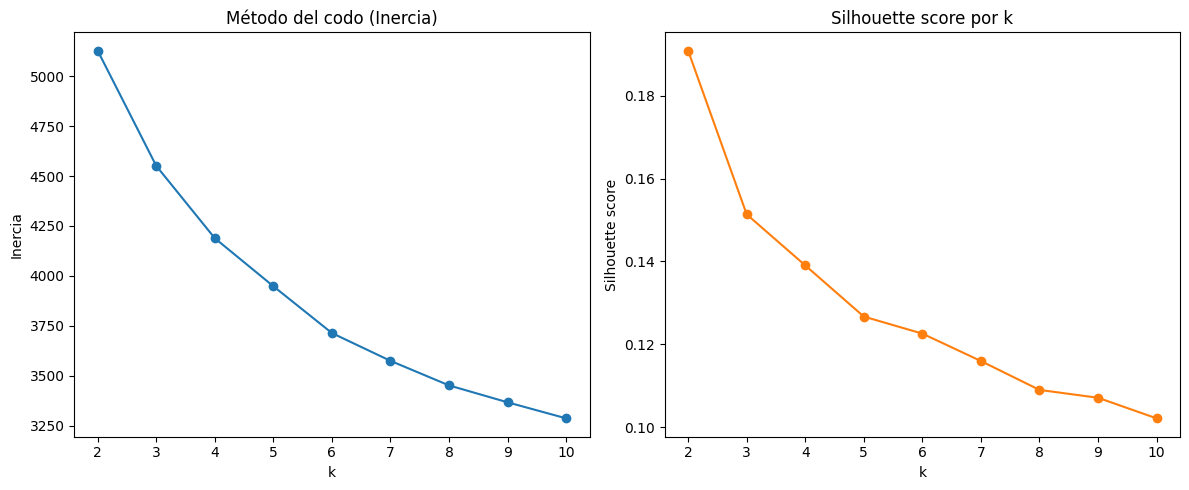

Mejor k por silhouette: 2


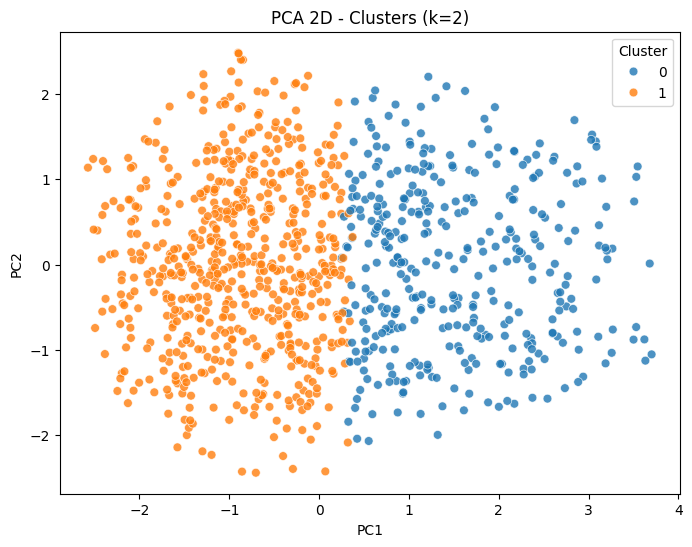

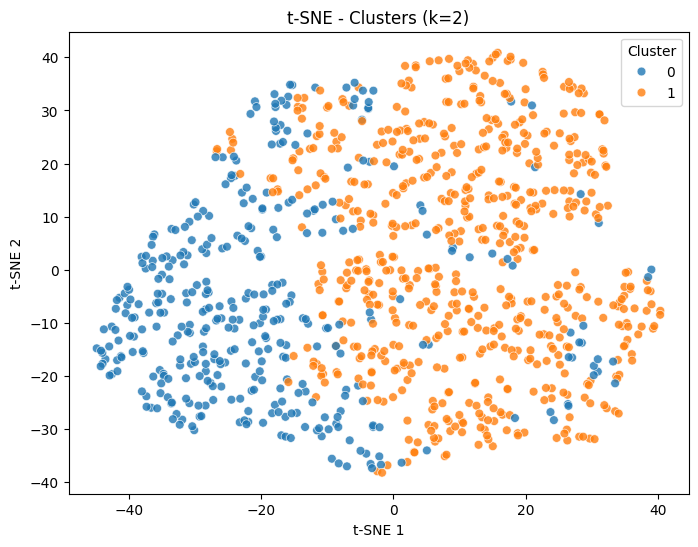

Tamaño por cluster:
cluster_best
0    369
1    631
Name: count, dtype: int64
                   Total                   Unit price                   \
                    mean         std count       mean        std count   
cluster_best                                                             
0             594.546167  179.101574   369  73.367805  18.864193   369   
1             164.150893   93.125169   631  45.323946  24.790859   631   

                Rating                  Quantity                 combo_freq  \
                  mean       std count      mean       std count       mean   
cluster_best                                                                  
0             6.911111  1.777199   369  7.902439  1.781920   369   0.042683   
1             7.008716  1.683742   631  4.110935  2.526757   631   0.042345   

                              
                   std count  
cluster_best                  
0             0.005802   369  
1             0.005560   631  


In [15]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Columnas (ajusta si es necesario)
num_cols = ["Total", "Unit price", "Rating", "Quantity"]
cat_cols = ["Customer type", "Gender", "Product line", "Payment"]

# 1) Crear columna combinada si no existe
if "combo" not in df.columns:
    df["combo"] = df[cat_cols].astype(str).agg("_".join, axis=1)

# 2) Agrupar combinaciones raras (umbral absoluto)
min_count = 10
combo_counts = df["combo"].value_counts()
rare_combos = combo_counts[combo_counts < min_count].index
df["combo_grouped"] = df["combo"].where(~df["combo"].isin(rare_combos), "Other")

# 3) Codificación de la combinación: frequency encoding (numérica, útil para clustering)
combo_freq = df["combo_grouped"].value_counts(normalize=True).to_dict()
df["combo_freq"] = df["combo_grouped"].map(combo_freq)

# 4) OneHotEncode para las categóricas principales (handle_unknown para seguridad)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
cat_ohe = ohe.fit_transform(df[cat_cols])
cat_ohe_cols = ohe.get_feature_names_out(cat_cols)

# 5) Escalar numéricas
scaler = StandardScaler()
num_scaled = scaler.fit_transform(df[num_cols])

# 6) Construir matriz final de features para clustering
X = np.hstack([num_scaled, cat_ohe, df[["combo_freq"]].values])

# 7) Evaluar k en rango 2..10: inercia y silhouette
ks = list(range(2, 11))
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# 8) Graficar inercia (codo) y silhouette
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(ks, inertias, marker="o")
plt.xticks(ks)
plt.xlabel("k")
plt.ylabel("Inercia")
plt.title("Método del codo (Inercia)")

plt.subplot(1,2,2)
plt.plot(ks, silhouettes, marker="o", color="tab:orange")
plt.xticks(ks)
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score por k")

plt.tight_layout()
plt.show()

# 9) Elegir k con mejor silhouette y recalcular clusters
best_k = ks[int(np.argmax(silhouettes))]
print(f"Mejor k por silhouette: {best_k}")

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=50)
labels_best = km_best.fit_predict(X)
df["cluster_best"] = labels_best

# 10) Visualización 2D con PCA(2)
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=labels_best, palette="tab10", s=40, alpha=0.8)
plt.title(f"PCA 2D - Clusters (k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1,1))
plt.show()

# 11) Visualización 2D con t-SNE (usar PCA previo para acelerar)
pca_pre = PCA(n_components=min(30, X.shape[1]), random_state=42)
X_pca_pre = pca_pre.fit_transform(X)

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca_pre)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels_best, palette="tab10", s=40, alpha=0.8)
plt.title(f"t-SNE - Clusters (k={best_k})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1,1))
plt.show()

# 12) Resumen rápido por cluster
print("Tamaño por cluster:")
print(df["cluster_best"].value_counts().sort_index())

cluster_summary = df.groupby("cluster_best")[num_cols + ["combo_freq"]].agg(["mean","std","count"])
print(cluster_summary)